# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [63]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [64]:
%pip install matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [65]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

# Define the path to your data folder
DATA_DIR = '../data/'

# 1. Load the Demographics Data
print("Loading studentInfo.csv...")
student_info = pd.read_csv(f"{DATA_DIR}studentInfo.csv")
print(f"✅ studentInfo loaded: {student_info.shape[0]:,} rows x {student_info.shape[1]} columns")

# 2. Load the VLE Resource Mapping Data
print("Loading vle.csv...")
vle_mapping = pd.read_csv(f"{DATA_DIR}vle.csv")
print(f"✅ vle_mapping loaded: {vle_mapping.shape[0]:,} rows x {vle_mapping.shape[1]} columns")

# 3. Load the Big Data Clickstream (studentVle.csv)
print("Loading studentVle.csv (The Big Data file) - please wait...")
student_vle = pd.read_csv(f"{DATA_DIR}studentVle.csv")
print(f"✅ studentVle loaded: {student_vle.shape[0]:,} rows x {student_vle.shape[1]} columns")

Loading studentInfo.csv...
✅ studentInfo loaded: 32,593 rows x 12 columns
Loading vle.csv...
✅ vle_mapping loaded: 6,364 rows x 6 columns
Loading studentVle.csv (The Big Data file) - please wait...
✅ studentVle loaded: 10,655,280 rows x 6 columns


In [66]:
# 1. Calculate total clicks for each student from the VLE dataset
student_clicks = student_vle.groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().reset_index()

# 2. Merge the student information with their total clicks
df_integrated = pd.merge(student_info, student_clicks, on=['id_student', 'code_module', 'code_presentation'], how='left')

# 3. Fill missing clicks with 0 (for students who never clicked anything)
df_integrated['sum_click'] = df_integrated['sum_click'].fillna(0)

print("✅ Data successfully merged into 'df_integrated'!")
display(df_integrated.head(2))

✅ Data successfully merged into 'df_integrated'!


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,sum_click
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0


In [67]:
# Verify the data by displaying a random sample from each table
print("--- Sample from studentInfo ---")
display(student_info.sample(3))

print("\n--- Sample from vle_mapping ---")
display(vle_mapping.sample(3))

print("\n--- Sample from studentVle (Clickstream) ---")
display(student_vle.sample(3))

--- Sample from studentInfo ---


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
20133,EEE,2013J,597181,M,West Midlands Region,A Level or Equivalent,20-30%,0-35,0,60,N,Fail
10252,CCC,2014B,632111,M,North Western Region,A Level or Equivalent,50-60%,0-35,0,60,N,Pass
30816,GGG,2013J,603763,F,West Midlands Region,Lower Than A Level,10-20,0-35,0,30,Y,Pass



--- Sample from vle_mapping ---


,id_site,code_module,code_presentation,activity_type,week_from,week_to
5331,779730,FFF,2014B,url,9.0,9.0
2353,547737,DDD,2013B,resource,NaN,NaN
4576,716940,FFF,2013J,url,23.0,23.0



--- Sample from studentVle (Clickstream) ---


,code_module,code_presentation,id_student,id_site,date,sum_click
4797717,DDD,2014J,685294,813701,4,9
8969209,FFF,2014B,634616,779433,191,4
6803794,FFF,2013B,549420,526767,98,14


In [68]:
data_source_report = {
    "source": "Open University Learning Analytics Dataset (OULAD)",
    "acquisition_method": "Downloaded CSV archive from official KMi repository",
    "date_acquired": "March 2026",
    "issues_encountered": ["studentVle.csv is highly memory-intensive (~400MB) due to 10M+ rows. Required loading directly into Pandas without Excel."]
}
print(data_source_report)

{'source': 'Open University Learning Analytics Dataset (OULAD)', 'acquisition_method': 'Downloaded CSV archive from official KMi repository', 'date_acquired': 'March 2026', 'issues_encountered': ['studentVle.csv is highly memory-intensive (~400MB) due to 10M+ rows. Required loading directly into Pandas without Excel.']}


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [69]:
print("=== 1. Student Info Schema ===")
student_info.info()

print("\n" + "="*40 + "\n")

print("=== 2. VLE Mapping Schema ===")
vle_mapping.info()

print("\n" + "="*40 + "\n")

print("=== 3. Student VLE Clickstream Schema ===")
student_vle.info()

=== 1. Student Info Schema ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


=== 2. VLE Mapping Schema ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data

In [70]:


print("=== Student Info (Categorical) ===")
display(student_info.describe(include='object'))

print("\n=== Breakdown of Final Results (Our Target Variable) ===")

display(student_info['final_result'].value_counts())

=== Student Info (Categorical) ===


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,disability,final_result
count,32593,32593,32593,32593,32593,31482,32593,32593,32593
unique,7,4,2,13,5,10,3,2,4
top,BBB,2014J,M,Scotland,A Level or Equivalent,20-30%,0-35,N,Pass
freq,7909,11260,17875,3446,14045,3654,22944,29429,12361



=== Breakdown of Final Results (Our Target Variable) ===


final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [ ]:
# Task 2: Descriptive Statistics
 
print("=== Comprehensive Descriptive Statistics ===")
display(df_integrated.describe(include='all'))

print("\n💡 Insights:")
print("- We can see the most common regions and gender distribution.")
print("- The 'sum_click' max value is much higher than the mean, suggesting outliers.")

=== Comprehensive Descriptive Statistics ===


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,sum_click
count,32593,32593,3.259300e+04,32593,32593,32593,31482,32593,32593.000000,32593.000000,32593,32593,32593.000000
unique,7,4,NaN,2,13,5,10,3,NaN,NaN,2,4,NaN
top,BBB,2014J,NaN,M,Scotland,A Level or Equivalent,20-30%,0-35,NaN,NaN,N,Pass,NaN
freq,7909,11260,NaN,17875,3446,14045,3654,22944,NaN,NaN,29429,12361,NaN
mean,NaN,NaN,7.066877e+05,NaN,NaN,NaN,NaN,NaN,0.163225,79.758691,NaN,NaN,1215.141257
std,NaN,NaN,5.491673e+05,NaN,NaN,NaN,NaN,NaN,0.479758,41.071900,NaN,NaN,1692.604449
min,NaN,NaN,3.733000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,NaN,NaN,0.000000
25%,NaN,NaN,5.085730e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN,142.000000
50%,NaN,NaN,5.903100e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN,602.000000
75%,NaN,NaN,6.444530e+05,NaN,NaN,NaN,NaN,NaN,0.000000,120.000000,NaN,NaN,1585.000000



💡 Insights:
- We can see the most common regions and gender distribution.
- The 'sum_click' max value is much higher than the mean, suggesting outliers.


---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

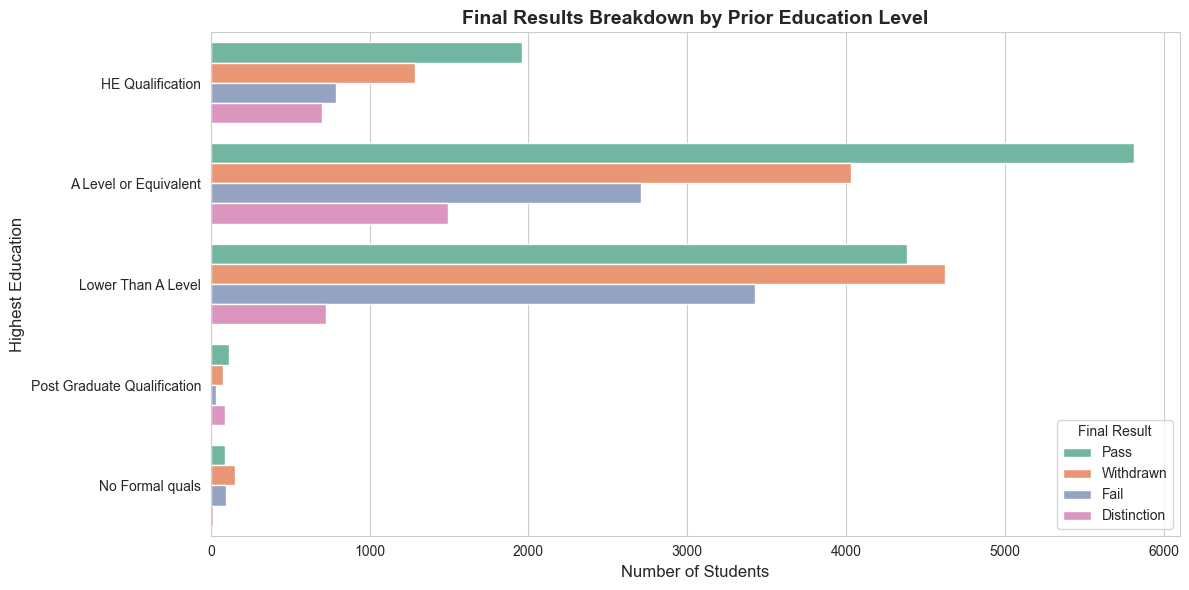

In [37]:

plt.figure(figsize=(12, 6))
sns.countplot(data=student_info, 
              y='highest_education', 
              hue='final_result', 
              palette='Set2')

plt.title('Final Results Breakdown by Prior Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Number of Students', fontsize=12)
plt.ylabel('Highest Education', fontsize=12)
plt.legend(title='Final Result')
plt.tight_layout()
plt.show()

In [38]:

initial_insights = [
    "Insight 1: 'Withdrawn' is the second most common outcome (10,156 students). This massive dropout rate validates our business objective.",
    "Insight 2: We have a multi-class target variable. To simplify our model later, we should map 'Pass/Distinction' to 0 (Retained) and 'Fail/Withdrawn' to 1 (Dropped Out).",
    "Hypothesis 1: Students with lower prior education levels (e.g., 'Lower Than A Level') may have higher withdrawal rates, making them a high-risk demographic.",
    "Hypothesis 2: Integrating the VLE clickstream data will provide a stronger behavioral predictor of withdrawal than demographics alone."
]

print("=== EDA Insights & Hypotheses ===")
for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")

=== EDA Insights & Hypotheses ===
1. Insight 1: 'Withdrawn' is the second most common outcome (10,156 students). This massive dropout rate validates our business objective.
2. Insight 2: We have a multi-class target variable. To simplify our model later, we should map 'Pass/Distinction' to 0 (Retained) and 'Fail/Withdrawn' to 1 (Dropped Out).
3. Hypothesis 1: Students with lower prior education levels (e.g., 'Lower Than A Level') may have higher withdrawal rates, making them a high-risk demographic.
4. Hypothesis 2: Integrating the VLE clickstream data will provide a stronger behavioral predictor of withdrawal than demographics alone.


C:\Users\Mohamed El Gaby\AppData\Local\Temp\ipykernel_11216\1004977330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_band', data=df_integrated, palette='viridis')


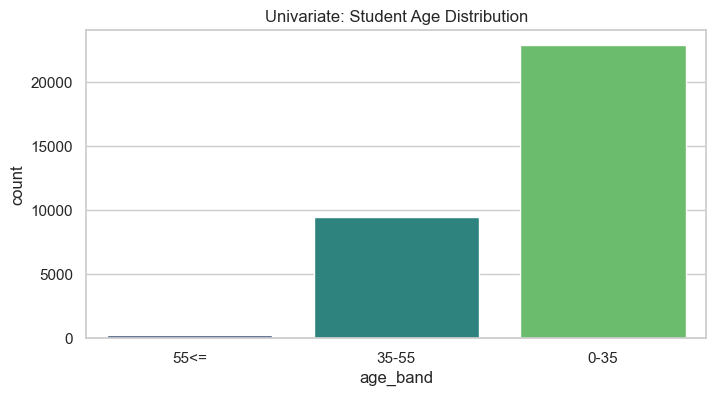

💡 INSIGHT: Most students are in the 0-35 age range.



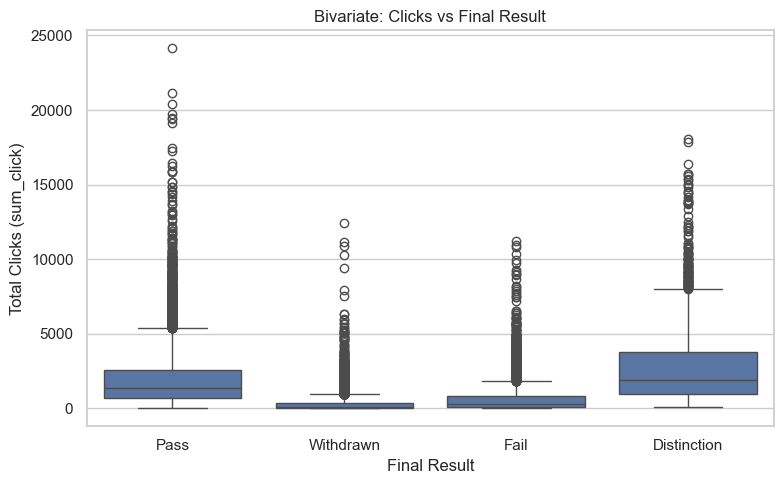

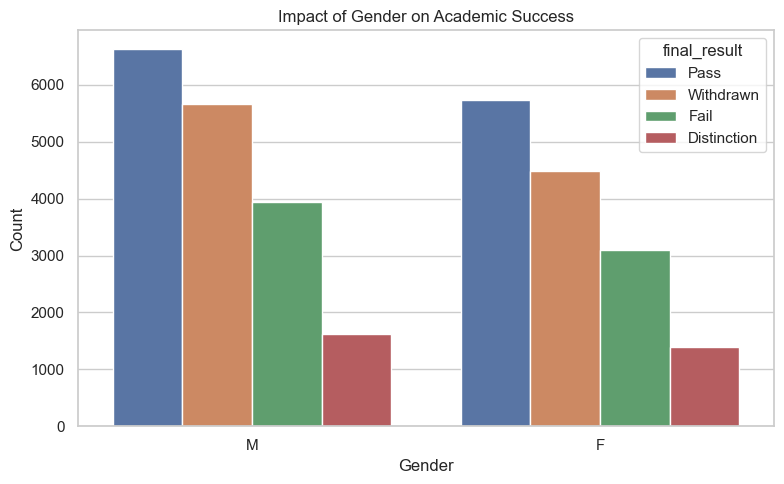

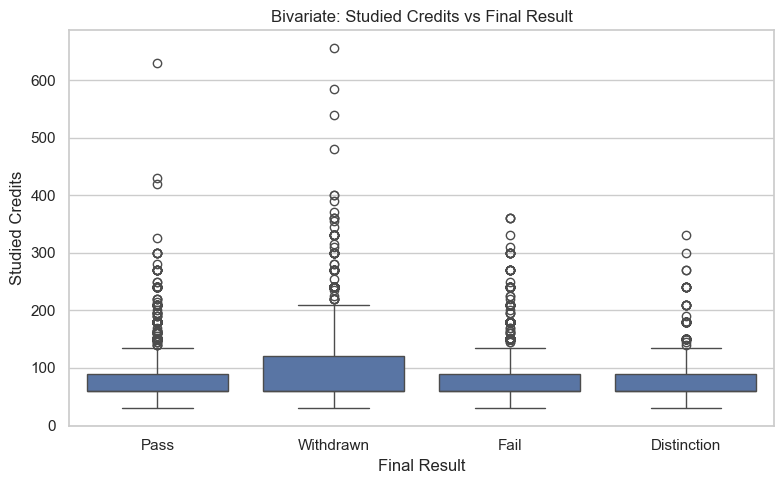

💡 INSIGHT: Students with Pass and Distinction generally show higher click activity.
💡 INSIGHT: Studied credits show some variation across final result categories.
💡 INSIGHT: Gender distribution differs across outcomes, but the effect appears less pronounced than click activity.


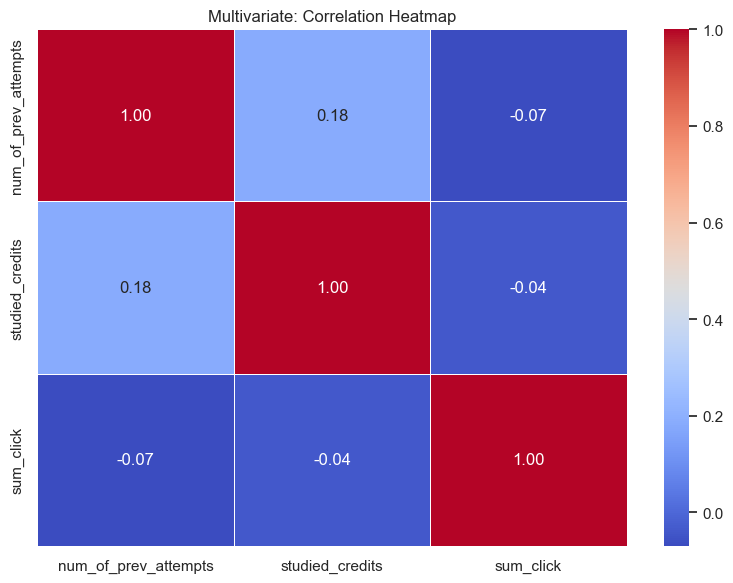

💡 INSIGHT: The numerical features show weak to moderate correlations overall.
💡 INSIGHT: No strong multicollinearity is observed among the main numerical variables.
💡 INSIGHT: This supports the inclusion of these variables in later modeling stages.


In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# 1. Univariate Analysis
plt.figure(figsize=(8, 4))
sns.countplot(x='age_band', data=df_integrated, palette='viridis')
plt.title('Univariate: Student Age Distribution')
plt.show()
print("💡 INSIGHT: Most students are in the 0-35 age range.\n")

# 2. Bivariate Analysis

# Bivariate 1: Clicks vs Final Result
plt.figure(figsize=(8, 5))
sns.boxplot(x='final_result', y='sum_click', data=df_integrated)
plt.title('Bivariate: Clicks vs Final Result')
plt.xlabel('Final Result')
plt.ylabel('Total Clicks (sum_click)')
plt.tight_layout()
plt.show()

# Bivariate 2: Gender vs Final Result
plt.figure(figsize=(8, 5))
sns.countplot(data=df_integrated, x='gender', hue='final_result')
plt.title('Impact of Gender on Academic Success')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Bivariate 3: Studied Credits vs Final Result
plt.figure(figsize=(8, 5))
sns.boxplot(x='final_result', y='studied_credits', data=df_integrated)
plt.title('Bivariate: Studied Credits vs Final Result')
plt.xlabel('Final Result')
plt.ylabel('Studied Credits')
plt.tight_layout()
plt.show()

print("💡 INSIGHT: Students with Pass and Distinction generally show higher click activity.")
print("💡 INSIGHT: Studied credits show some variation across final result categories.")
print("💡 INSIGHT: Gender distribution differs across outcomes, but the effect appears less pronounced than click activity.")

# 3. Multivariate Analysis

# Select numerical columns and remove identifier columns that are not analytically meaningful
numeric_cols = df_integrated.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if col != 'id_student']

# Create the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_integrated[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Multivariate: Correlation Heatmap')
plt.tight_layout()
plt.show()

print("💡 INSIGHT: The numerical features show weak to moderate correlations overall.")
print("💡 INSIGHT: No strong multicollinearity is observed among the main numerical variables.")
print("💡 INSIGHT: This supports the inclusion of these variables in later modeling stages.")

---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [83]:

# Group all datasets to check missing values in one loop
datasets = {
    "Student Info": student_info,
    "VLE Mapping": vle_mapping,
    "Student VLE (Clickstream)": student_vle
}

for name, df in datasets.items():
    # Count missing values per column
    missing = df.isnull().sum()
    
    # Calculate missing percentage
    missing_pct = (missing / len(df)) * 100
    
    # Create a report table
    missing_report = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct
    })
    
    # Keep only columns with missing values
    missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

    # Print dataset name and display report
    print(f"\n=== {name} Missing Values ===")
    if len(missing_report) > 0:
        display(missing_report.round(2))
    else:
        print("No missing values detected! ✅")


=== Student Info Missing Values ===


,Missing Count,Missing %
imd_band,1111,3.41



=== VLE Mapping Missing Values ===


,Missing Count,Missing %
week_from,5243,82.39
week_to,5243,82.39



=== Student VLE (Clickstream) Missing Values ===
No missing values detected! ✅


In [40]:



for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"=== {name} Duplicates ===")
    print(f"Number of duplicate rows: {duplicates:,}")
    
    
    if duplicates > 0 and name == "Student VLE (Clickstream)":
        print("\nSample of duplicate clickstream rows:")
        display(df[df.duplicated(keep=False)].sort_values(['id_student', 'date']).head(4))
    print("\n")

=== Student Info Duplicates ===
Number of duplicate rows: 0


=== VLE Mapping Duplicates ===
Number of duplicate rows: 0


=== Student VLE (Clickstream) Duplicates ===
Number of duplicate rows: 787,170

Sample of duplicate clickstream rows:


,code_module,code_presentation,id_student,id_site,date,sum_click
191989,AAA,2014J,6516,877025,-6,6
191991,AAA,2014J,6516,877025,-6,6
194380,AAA,2014J,6516,877025,-2,1
194384,AAA,2014J,6516,877025,-2,1


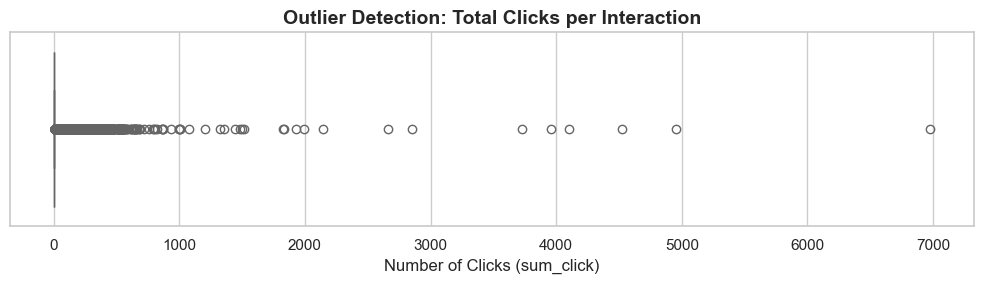

Number of interactions with > 100 clicks: 6,757 out of 10,655,280


In [84]:

# --- Task 4: Visual Outlier Detection for Clickstream Activity ---

# Create a boxplot to visually inspect extreme values in the sum_click column
# This helps us quickly detect whether the clickstream data contains unusually large values
plt.figure(figsize=(10, 3))
sns.boxplot(x=student_vle['sum_click'], color='coral')

# Add title and axis label for clarity
plt.title('Outlier Detection: Total Clicks per Interaction', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clicks (sum_click)', fontsize=12)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

# Define a manual threshold to count very large click values
# Here, any interaction with more than 100 clicks is treated as an extreme outlier
outlier_threshold = 100

# Count how many rows exceed this threshold
extreme_outliers = len(student_vle[student_vle['sum_click'] > outlier_threshold])

# Print the result to show how many extreme outliers exist in the clickstream dataset
print(f"Number of interactions with > {outlier_threshold} clicks: {extreme_outliers:,} out of {len(student_vle):,}")

In [77]:
 # Task 4: IQR Outlier Detection for All Numerical Features

numerical_features = ['num_of_prev_attempts', 'studied_credits', 'sum_click']

print("=== Outlier Verification Using IQR ===\n")

iqr_results = {}

for col in numerical_features:
    Q1 = df_integrated[col].quantile(0.25)
    Q3 = df_integrated[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_integrated[(df_integrated[col] < lower_bound) | (df_integrated[col] > upper_bound)]
    outliers_count = len(outliers)

    iqr_results[col] = outliers_count

    print(f"Column: {col}")
    print(f"Normal Range: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Outliers Count: {outliers_count}")
    print("-" * 50)

=== Outlier Verification Using IQR ===

Column: num_of_prev_attempts
Normal Range: [0.00, 0.00]
Outliers Count: 4172
--------------------------------------------------
Column: studied_credits
Normal Range: [-30.00, 210.00]
Outliers Count: 350
--------------------------------------------------
Column: sum_click
Normal Range: [-2022.50, 3749.50]
Outliers Count: 2503
--------------------------------------------------


In [78]:
# Task 4: Complete Data Quality Check

# 1. Check for Missing Values
print("=== 1. Missing Values Check ===")
print(df_integrated.isnull().sum())
print("-" * 30)

# 2. Check for Duplicates
print("=== 2. Duplicates Check ===")
duplicates = df_integrated.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")
print("-" * 30)

print("\n=== 3. Outlier Verification (IQR) ===")
for col, count in iqr_results.items():
    print(f"{col}: {count} outliers detected")

=== 1. Missing Values Check ===
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
sum_click                  0
dtype: int64
------------------------------
=== 2. Duplicates Check ===
Total Duplicate Rows: 0
------------------------------

=== 3. Outlier Verification (IQR) ===
num_of_prev_attempts: 4172 outliers detected
studied_credits: 350 outliers detected
sum_click: 2503 outliers detected


In [82]:
final_report = """
------------------------------------------------------------
FINAL DATA QUALITY REPORT & ACTION PLAN (PHASE 2)
------------------------------------------------------------

1. OUTLIERS DETECTION:
   - Finding: IQR analysis detected outliers in multiple numerical features:
     4,172 in 'num_of_prev_attempts', 350 in 'studied_credits', and 2,503 in 'sum_click'.
   - Action: We will handle these outliers in Phase 3 using robust preprocessing techniques, especially for skewed numerical variables.

2. MISSING VALUES:
   - Finding: Missing values were identified in the 'imd_band' column.
   - Action: We will perform mode imputation to fill the missing values.

3. DATA REDUNDANCY:
   - Finding: The 'id_student' column is an identifier and not useful for modeling, and no duplicate rows were found in the integrated dataset.
   - Action: We will remove irrelevant identifier columns before modeling.

4. DATA TRANSFORMATION:
   - Finding: The target variable and categorical features require numerical encoding before modeling.
   - Action: We will apply encoding techniques in Phase 3.

CONCLUSION: The dataset has been verified and is ready for Phase 3: Data Preparation.
"""

print(final_report)


------------------------------------------------------------
FINAL DATA QUALITY REPORT & ACTION PLAN (PHASE 2)
------------------------------------------------------------

1. OUTLIERS DETECTION:
   - Finding: IQR analysis detected outliers in multiple numerical features:
     4,172 in 'num_of_prev_attempts', 350 in 'studied_credits', and 2,503 in 'sum_click'.
   - Action: We will handle these outliers in Phase 3 using robust preprocessing techniques, especially for skewed numerical variables.

2. MISSING VALUES:
   - Finding: Missing values were identified in the 'imd_band' column.
   - Action: We will perform mode imputation to fill the missing values.

3. DATA REDUNDANCY:
   - Finding: The 'id_student' column is an identifier and not useful for modeling, and no duplicate rows were found in the integrated dataset.
   - Action: We will remove irrelevant identifier columns before modeling.

4. DATA TRANSFORMATION:
   - Finding: The target variable and categorical features require nume